##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loaded 1 cat images and 3 dog images (4 total)
CLS token matrix shape: (4, 384)

Clustering Accuracy: 100.0%
Confusion Matrix:
[[1 0]
 [0 3]]


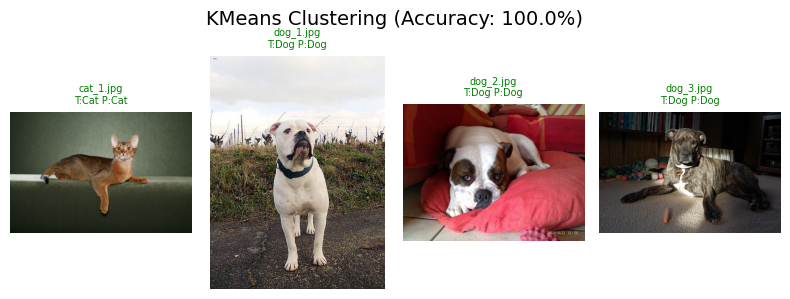

In [11]:
# Exercise 1: Unsupervised Clustering
!pip install -q transformers torch torchvision scikit-learn

import torch
import numpy as np
import glob
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Load DINOv2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small").to(device)
model.eval()

# Load local images — expects filenames like cat_1.jpg, dog_1.jpg, etc.
cat_files = sorted(glob.glob("cat_*.jpg"))
dog_files = sorted(glob.glob("dog_*.jpg"))

all_samples = []
for f in cat_files:
    all_samples.append((Image.open(f).convert("RGB"), 0, f))  # 0 = cat
for f in dog_files:
    all_samples.append((Image.open(f).convert("RGB"), 1, f))  # 1 = dog

print(f"Loaded {len(cat_files)} cat images and {len(dog_files)} dog images ({len(all_samples)} total)")

# Extract 384-dim CLS tokens
cls_tokens, ground_truth = [], []
with torch.no_grad():
    for img, label, fname in all_samples:
        inputs = processor(images=img, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls_tokens.append(outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten())
        ground_truth.append(label)

cls_tokens = np.array(cls_tokens)
ground_truth = np.array(ground_truth)
print(f"CLS token matrix shape: {cls_tokens.shape}")

# KMeans clustering (n=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
predicted = kmeans.fit_predict(cls_tokens)

# Fix arbitrary label assignment
if accuracy_score(ground_truth, 1 - predicted) > accuracy_score(ground_truth, predicted):
    predicted = 1 - predicted

accuracy = accuracy_score(ground_truth, predicted)
cm = confusion_matrix(ground_truth, predicted)
print(f"\nClustering Accuracy: {accuracy * 100:.1f}%")
print(f"Confusion Matrix:\n{cm}")

# Visualize
n = len(all_samples)
cols = min(n, 10)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 3 * rows))
if rows == 1:
    axes = [axes] if cols == 1 else [axes]
axes_flat = np.array(axes).flatten()
fig.suptitle(f"KMeans Clustering (Accuracy: {accuracy*100:.1f}%)", fontsize=14)
for i, (img, true_label, fname) in enumerate(all_samples):
    axes_flat[i].imshow(img)
    axes_flat[i].axis("off")
    color = "green" if predicted[i] == true_label else "red"
    axes_flat[i].set_title(f"{fname}\nT:{'Cat' if true_label==0 else 'Dog'} P:{'Cat' if predicted[i]==0 else 'Dog'}", fontsize=7, color=color)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")
plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

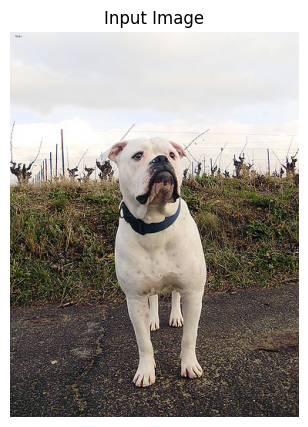

Top-5 Predictions:
---------------------------------------------
  1. Staffordshire bullterrier, Staffordshire bull terrier 44.12%
  2. American Staffordshire terrier, Staffordshire terrier, American pit bull terrier, pit bull terrier 26.63%
  3. bull mastiff                   18.34%
  4. boxer                          8.76%
  5. muzzle                         0.56%

Final Prediction: Staffordshire bullterrier, Staffordshire bull terrier (44.12% confidence)


In [13]:
# Exercise 2: Image Classification with DINOv2
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import matplotlib.pyplot as plt

# Load DINOv2 with ImageNet-1k classification head
model_id = "facebook/dinov2-small-imagenet1k-1-layer"
processor = AutoImageProcessor.from_pretrained(model_id)
classifier = AutoModelForImageClassification.from_pretrained(model_id)
classifier.eval()

# Use a local image
image = Image.open("dog_1.jpg").convert("RGB")
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Run inference
inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    logits = classifier(**inputs).logits

probs = torch.nn.functional.softmax(logits, dim=-1)
top5_probs, top5_indices = torch.topk(probs, 5)

print("Top-5 Predictions:")
print("-" * 45)
for i in range(5):
    label = classifier.config.id2label[top5_indices[0][i].item()]
    prob = top5_probs[0][i].item()
    print(f"  {i+1}. {label:<30} {prob*100:.2f}%")

predicted_label = classifier.config.id2label[logits.argmax(-1).item()]
confidence = probs[0][logits.argmax(-1).item()].item()
print(f"\nFinal Prediction: {predicted_label} ({confidence*100:.2f}% confidence)")